# Task 3: Helper notebook for loading the data and saving the predictions

In [1]:
import pickle
import gzip
import numpy as np
import os

### Helper functions

In [2]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

In [3]:
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

### Load data, make predictions and save prediction in correct format

In [4]:
# load data
train_data = load_zipped_pickle("data/train.pkl")
test_data = load_zipped_pickle("data/test.pkl")
samples = load_zipped_pickle("data/sample.pkl")

In [5]:
shapes_train = [sample['video'].shape for sample in train_data]
shapes_train

[(112, 112, 334),
 (112, 112, 177),
 (112, 112, 195),
 (112, 112, 181),
 (112, 112, 211),
 (112, 112, 209),
 (112, 112, 129),
 (112, 112, 179),
 (112, 112, 168),
 (112, 112, 151),
 (112, 112, 113),
 (112, 112, 214),
 (112, 112, 151),
 (112, 112, 166),
 (112, 112, 210),
 (112, 112, 118),
 (112, 112, 177),
 (112, 112, 171),
 (112, 112, 258),
 (112, 112, 173),
 (112, 112, 190),
 (112, 112, 109),
 (112, 112, 206),
 (112, 112, 196),
 (112, 112, 114),
 (112, 112, 176),
 (112, 112, 177),
 (112, 112, 190),
 (112, 112, 201),
 (112, 112, 178),
 (112, 112, 128),
 (112, 112, 215),
 (112, 112, 174),
 (112, 112, 221),
 (112, 112, 150),
 (112, 112, 179),
 (112, 112, 141),
 (112, 112, 140),
 (112, 112, 184),
 (112, 112, 159),
 (112, 112, 154),
 (112, 112, 172),
 (112, 112, 155),
 (112, 112, 216),
 (112, 112, 162),
 (112, 112, 198),
 (587, 647, 76),
 (585, 760, 83),
 (730, 772, 54),
 (583, 782, 90),
 (583, 810, 94),
 (579, 844, 116),
 (583, 796, 71),
 (584, 674, 85),
 (731, 765, 70),
 (583, 628, 79),
 

In [ ]:
# make prediction for test
predictions = []
for d in test_data:
    prediction = np.array(np.zeros_like(d['video']), dtype=np.bool)
    height = prediction.shape[0]
    width = prediction.shape[1]
    prediction[int(height/2)-50:int(height/2+50), int(width/2)-50:int(width/2+50)] = True
    
    # DATA Strucure
    predictions.append({
        'name': d['name'],
        'prediction': prediction
        }
    )

In [ ]:
# save in correct format
save_zipped_pickle(predictions, 'my_predictions.pkl')

In [6]:
from preprocessing import STANDARD_IMAGE_PROCESSOR



img = train_data[0]['video'][:, :, 0]
img.shape

(112, 112)

In [7]:
#bi(video[:, :, 0])
#cv2.medianBlur(video[:, :, 0], 3)
processed_img = STANDARD_IMAGE_PROCESSOR.process_image(img)
processed_img.shape

(112, 112, 3)

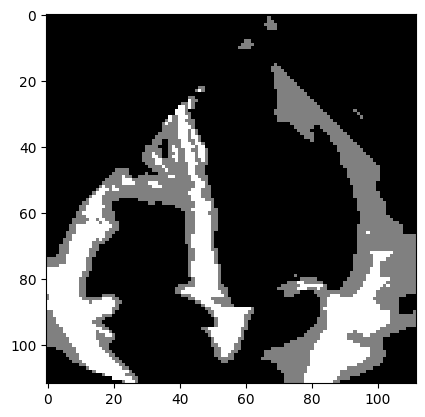

In [10]:
import util

util.show_img(processed_img[:, :, 2])